In [10]:
!pip install ultralytics roboflow

In [11]:
from roboflow import Roboflow
rf = Roboflow(api_key="sEOPxTi6Mj1L5uWPpVHK")
project = rf.workspace("fakelogodetection-kyw5i").project("fale-real-dwxlj")
version = project.version(2)
dataset = version.download("yolov8")
print("✅ Dataset Download Complete")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fale/real-2 in yolov8:: 100%|██████████| 182/182 [00:00<00:00, 7319.62it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Dataset Download Complete


In [12]:
import os

# Automatically search for the data.yaml file in the current directory
data_yaml_path = None
for root, dirs, files in os.walk('/content'):
    if 'data.yaml' in files:
        # We assume the correct one is inside a folder like 'fale-real-dwxlj-2'
        if 'fale-real' in root or 'Fale-real' in root or 'fale' in root:
             data_yaml_path = os.path.join(root, 'data.yaml')
             print(f"✅ SUCCESS: Found data.yaml at: {data_yaml_path}")
             break

if data_yaml_path is None:
    print("❌ ERROR: Could not auto-find data.yaml. Please check the file browser manually.")

✅ SUCCESS: Found data.yaml at: /content/fale/real-2/data.yaml


In [13]:
from ultralytics import YOLO
import os

# --- Your provided data.yaml path ---
data_yaml_path = '/content/fale/real-2/data.yaml'

# Check if the file exists before starting (Just to be safe)
if not os.path.exists(data_yaml_path):
    print(f"❌ Error: Could not find file at {data_yaml_path}")
    print("Please check the file browser on the left to confirm the path.")
else:
    print(f"✅ Found data.yaml at: {data_yaml_path}")
    print("Starting training...")

    # Load a pre-trained model
    model = YOLO('yolov8s.pt')

    # Train on your new dataset
    results = model.train(data=data_yaml_path,
                          epochs=100,
                          imgsz=640,
                          project='runs/detect',
                          name='train_fale_real_v2')

    # Find the path to the best model automatically
    latest_run_dir = os.path.join('runs/detect', 'train_fale_real_v2')
    # Handle potential numbering (e.g., train_fale_real_v22) if you re-run
    if not os.path.exists(os.path.join(latest_run_dir, 'weights')):
        runs = [d for d in os.listdir('runs/detect') if d.startswith('train_fale_real_v2')]
        runs.sort()
        if runs:
            latest_run_dir = os.path.join('runs/detect', runs[-1])

    best_model_path = os.path.join(latest_run_dir, 'weights/best.pt')

    print(f"\n🏁 Training complete.")
    if os.path.exists(best_model_path):
      print(f"⬇️ Best model saved to: {best_model_path}")
      print("Copy this path for the next step!")
    else:
      print(f"ERROR: Training finished but best.pt not found! Checked in {latest_run_dir}")

✅ Found data.yaml at: /content/fale/real-2/data.yaml
Starting training...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fale/real-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_fale_real_v2, nbs=64, nms=False, opset=None, optimize=F

Loading model from: /content/runs/detect/train_fale_real_v2/weights/best.pt

Running prediction on: https://i.ebayimg.com/images/g/Y1AAAOSwY-NlK-qQ/s-l1600.jpg ...

image 1/1 /content/s-l1600.jpg: 640x640 (no detections), 16.3ms
Speed: 3.4ms preprocess, 16.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

❌ No detections found (Try training longer or checking dataset).


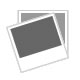

In [14]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import os

# --- Your specific model path ---
model_path = '/content/runs/detect/train_fale_real_v2/weights/best.pt'

# Check if the model exists
if not os.path.exists(model_path):
    print(f"ERROR: Model not found at {model_path}")
else:
    try:
        print(f"Loading model from: {model_path}")
        model = YOLO(model_path)

        # --- Test Image URL (Fake Gucci Example) ---
        # You can change this URL to test other images
        test_image_url = 'https://i.ebayimg.com/images/g/Y1AAAOSwY-NlK-qQ/s-l1600.jpg'

        print(f"\nRunning prediction on: {test_image_url} ...")

        # Run prediction
        results = model(test_image_url)

        # Print text results
        for result in results:
            boxes = result.boxes
            if boxes is not None and len(boxes) > 0:
                print(f"\n✅ Detections Found: {len(boxes)}")
                for box in boxes:
                    class_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    class_name = model.names[class_id]
                    print(f"   - Class: '{class_name}', Confidence: {confidence:.2f}")
            else:
                print("\n❌ No detections found (Try training longer or checking dataset).")

            # Show the image with boxes
            annotated_image = result.plot()
            cv2_imshow(annotated_image)

    except Exception as e:
        print(f"An error occurred: {e}")